In [498]:
import pandas as P

In [499]:
D = P.read_csv ("ECD.csv")

In [500]:
print(D.columns)

Index(['ID', 'Warehouse_block', 'Mode_of_Shipment', 'Customer_care_calls',
       'Customer_rating', 'Cost_of_the_Product', 'Prior_purchases',
       'Product_importance', 'Gender', 'Discount_offered', 'Weight_in_gms',
       'Reached.on.Time_Y.N'],
      dtype='object')


In [501]:
print(D.shape)

(10999, 12)


In [502]:
print(D.dtypes)

ID                      int64
Warehouse_block        object
Mode_of_Shipment       object
Customer_care_calls     int64
Customer_rating         int64
Cost_of_the_Product     int64
Prior_purchases         int64
Product_importance     object
Gender                 object
Discount_offered        int64
Weight_in_gms           int64
Reached.on.Time_Y.N     int64
dtype: object


In [503]:
from sklearn.preprocessing import LabelEncoder

In [504]:
LE = LabelEncoder ()

In [505]:
print(D.dtypes)

ID                      int64
Warehouse_block        object
Mode_of_Shipment       object
Customer_care_calls     int64
Customer_rating         int64
Cost_of_the_Product     int64
Prior_purchases         int64
Product_importance     object
Gender                 object
Discount_offered        int64
Weight_in_gms           int64
Reached.on.Time_Y.N     int64
dtype: object


In [506]:
D["Warehouse_block"] = LE.fit_transform(D["Warehouse_block"])
D["Mode_of_Shipment"] = LE.fit_transform(D["Mode_of_Shipment"])
D["Product_importance"] =  LE.fit_transform(D["Product_importance"])
D["Gender"] = LE.fit_transform (D["Gender"])

In [507]:
print(D.dtypes)

ID                     int64
Warehouse_block        int64
Mode_of_Shipment       int64
Customer_care_calls    int64
Customer_rating        int64
Cost_of_the_Product    int64
Prior_purchases        int64
Product_importance     int64
Gender                 int64
Discount_offered       int64
Weight_in_gms          int64
Reached.on.Time_Y.N    int64
dtype: object


In [508]:
MV = D.isnull ().sum ()
print(MV)

ID                     0
Warehouse_block        0
Mode_of_Shipment       0
Customer_care_calls    0
Customer_rating        0
Cost_of_the_Product    0
Prior_purchases        0
Product_importance     0
Gender                 0
Discount_offered       0
Weight_in_gms          0
Reached.on.Time_Y.N    0
dtype: int64


In [509]:
from sklearn.preprocessing import StandardScaler

In [510]:
SC = StandardScaler ()

In [511]:
Scaling = SC.fit_transform (D)

In [512]:
import matplotlib.pyplot as PLOT
import seaborn as SEA

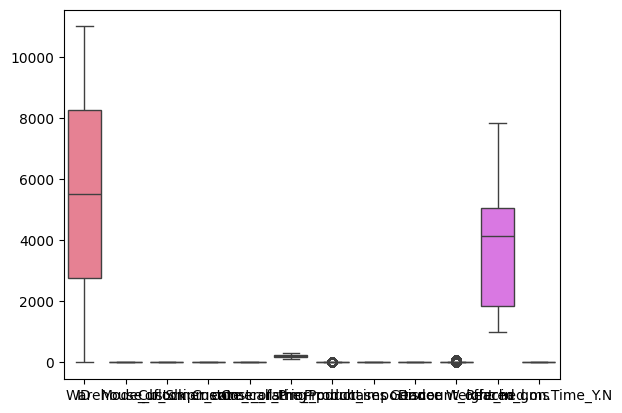

In [513]:
SEA.boxplot(D)
PLOT.show ()

In [514]:
Q1 = D.quantile (0.25)
Q3 = D.quantile (0.75)
IQR = Q3 - Q1
L = Q1 - (1.5 * IQR)
U = Q3 - (1.5 * IQR)
print(Q1)
print(Q3)
print(IQR)
print(L)
print(U)
print("\n")
DRO = D[((D >= L).all (axis = 1)) & ((D <= U).all (axis = 1))]
print(DRO)

ID                     2750.5
Warehouse_block           1.0
Mode_of_Shipment          1.0
Customer_care_calls       3.0
Customer_rating           2.0
Cost_of_the_Product     169.0
Prior_purchases           3.0
Product_importance        1.0
Gender                    0.0
Discount_offered          4.0
Weight_in_gms          1839.5
Reached.on.Time_Y.N       0.0
Name: 0.25, dtype: float64
ID                     8249.5
Warehouse_block           4.0
Mode_of_Shipment          2.0
Customer_care_calls       5.0
Customer_rating           4.0
Cost_of_the_Product     251.0
Prior_purchases           4.0
Product_importance        2.0
Gender                    1.0
Discount_offered         10.0
Weight_in_gms          5050.0
Reached.on.Time_Y.N       1.0
Name: 0.75, dtype: float64
ID                     5499.0
Warehouse_block           3.0
Mode_of_Shipment          1.0
Customer_care_calls       2.0
Customer_rating           2.0
Cost_of_the_Product      82.0
Prior_purchases           1.0
Product_importan

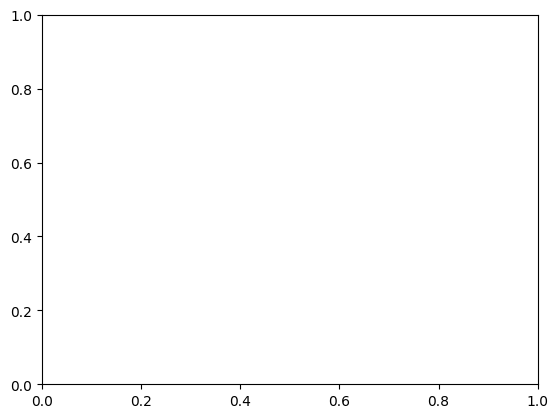

In [515]:
SEA.boxplot(DRO)
PLOT.show ()

In [516]:
Save_File = D.to_csv("ECD U.csv" , index = False)